# Импорт нужных библиотек

In [40]:
import pandas as pd
import sqlite3
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score
from joblib import dump, load
import openmeteo_requests
import tqdm
from statsmodels.tsa.arima.model import ARIMA
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px

from datetime import datetime

from evidently import Report
from evidently.presets import drift

# Создание класса для обучения моделей

In [71]:
class ModelTraining():
    """
    Класс для обучения моделей машинного обучения на данных.

    Attributes:
        sql_path(str): Путь к папке с базой данных
    """
    
    def __init__(self, sql_path: str):
        """
        Инициализация класса и подготовка датасета к прогонке через модели.
    
        Attributes:
            sql_path(str): Путь к папке с базой данных
        """

        # Инициализация класса Report для отчета дрейфа данных
        self.report = Report(metrics=[drift.DataDriftPreset()])
        
        # Инициализация таблицы с записью "логов"
        self.log = pd.DataFrame(columns=["time", "name_log", "model_name", "info"])
        
        # Включение игнорирования мешающих предупреждений
        warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
        # Загрузка базы данных
        try:
            con = sqlite3.connect(sql_path)
            self.data = pd.read_sql("SELECT * FROM Clear_data", con=con)
        except Exception as e:
            print(f"Ошибка в загрузке из базы данных: {e}")
            
        try:
            # Удаление не нужных в обучении колонок
            self.data = self.data.drop(["level_0", "index"], axis=1)
            self.data = self.data.drop(["country", "cluster_2", "point_id", "elevation", "steps"], axis=1)
            # Подготовка колонки со временем, а именно разделение ее на
            # отдельные колонки (date_day, date_month, date_year, date_hour)
            self.data["time"] = pd.to_datetime(self.data["time"])
            self.data['date_day'] = self.data['time'].dt.day
            self.data['date_month'] = self.data['time'].dt.month
            self.data['date_year'] = self.data['time'].dt.year
            self.data['date_hour'] = self.data['time'].dt.hour
            self.data = self.data.drop("time", axis=1)
        except Exception as e:
            print(f"Ошибка в оптимизации данных: {e}")

            
    def fit_model(self, target: str):
        """
        Обучает 3 модели и оценивает их качество
        Args:
            target(str): Название столбца с предказываемыми данными
        """

        # Разделение данных на выборки и обучение моделей
        self.target = target
        X_train, X_test, y_train, y_test = train_test_split(self.data.drop(target, axis=1), self.data[target], test_size=0.33, random_state=42)
        LR = LogisticRegression(max_iter=5000)
        LR.fit(X_train, y_train)
        GBC = GradientBoostingClassifier()
        GBC.fit(X_train, y_train)
        MLPC = MLPClassifier()
        MLPC.fit(X_train, y_train)
        self.models = {"MLPClassifier": MLPC, "GradientBoostingClassifier": GBC, "LogisticRegression": LR}
        # Проверка моделей по всем метрикам и вывод их результата
        for name_model in self.models:
            model = self.models[name_model]
            model_pred = model.predict(X_test)
            model_proba = model.predict_proba(X_test)
            print(f"Модель {name_model}:\n\nТочность: {accuracy_score(y_test, model_pred)}\nПолнота: {recall_score(y_test, model_pred, average="micro")}\nF1-метрика: {f1_score(y_test, model_pred, average="micro")}\nROC-AUC метрика: {roc_auc_score(y_true=y_test, y_score=model_proba[1, :], average="micro", multi_class="ovr")}\n\n")
        self.log = pd.concat([self.log, pd.DataFrame({"time": [datetime.now()], "name_log": ["Обучение моделей"], "model_name": ["*"], "info": ["Обучение трех моделей"]})], ignore_index=True)

    def save_model(self, model_name: str):
        """
        Сохраняет выбранную модель.
        Args:
            model_name(str): Имя выбранной модели
        """

        dump(self.models[model_name], f"{self.target}.joblib")
        self.log = pd.concat([self.log, pd.DataFrame({"time": [datetime.now()], "name_log": ["Сохранение модели"], "model_name": [model_name], "info": ["Сохранение модели в файл"]})], ignore_index=True)
        
    def __temperature_forecast(self, row):
        """
        С помощью API запроса получается температуру в определенной точке в определенную дату
        Args:
            row(pd.Series): Колонка со всей информацией
        """

        params = {
        "latitude": row["latitude"],
        "longitude": row["longitude"],
        "start_date": str(pd.to_datetime(f"{int(row["date_year"])}-{int(row["date_month"])}-{int(row["date_day"])}").strftime("%Y-%m-%d")),
        "end_date": str(pd.to_datetime(f"{int(row["date_year"])}-{int(row["date_month"])}-{int(row["date_day"])}").strftime("%Y-%m-%d")),
        "hourly": ["temperature_2m"]
        }
        
        try:
            openmeteo = openmeteo_requests.Client()
            responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
            response = responses[0]
            current = response.Hourly()
            temperatures = current.Variables(0).ValuesAsNumpy()
            return float(temperatures.mean())
        except Exception as e:
            print(f"Ошибка получения температуры на точке: {(row["latitude"], row["longitude"])}\n{e}")
            return 12

    def predictions(self, target: str, period: int, track: int):
        """
        Получение предсказание модели, на определенный срок вперед.
        Args:
            target(str): Колонка, которую будет предсказывать модель
            period(int): На сколько лет вперед будет предсказание
        """

        # Сортировка данных под выбранный маршрут
        self.points_predictions = {}
        data = self.data[self.data["track_id"] == track]
        # Проверка наличие сохраненной модели, обученной под этот таргет
        try:
            model = load(f"C:\\Users\\User\\Desktop\\Профики\\MachineLearning\\Проект №6 (последний срез)\\{target}.joblib")
        except Exception as e:
            return "Модели, обученной под этот target не было найдено!"
        for i in tqdm.tqdm(range(len(data.index.tolist()))):
            time_column = []
            temperature_column = []
            temperature_range = pd.DataFrame()
            predictions = []
            row = data.iloc[i]
            for k in range(4):
                row["date_year"] -= 1
                time_column.append(str(pd.to_datetime(f"{int(row["date_year"])}-{int(row["date_month"])}-{int(row["date_day"])}").strftime("%Y-%m-%d")))
                temperature_column.append(self.__temperature_forecast(row))
            temperature_range = pd.concat([temperature_range, pd.Series(temperature_column, name="temperature")], axis=1)
            temperature_range = pd.concat([temperature_range, pd.Series(time_column, name="time")], axis=1)
            temperature_range["time"] = pd.to_datetime(temperature_range["time"])
            temperature_range = temperature_range.set_index("time")
            temperature_range = temperature_range.iloc[::-1]
            model = ARIMA(temperature_range, order=(1,1,1))
            model_fit = model.fit()
            arima_predictions = model_fit.forecast(steps=period)
            
            for k, v in enumerate(arima_predictions):
                row = data.iloc[i]
                row["date_year"] += 1
                row["temperature"] = v
                model = load(f"C:\\Users\\User\\Desktop\\Профики\\MachineLearning\\Проект №6 (последний срез)\\{target}.joblib")
                predict = model.predict(pd.DataFrame(row).T.drop(target, axis=1))
                predictions.append(int(predict))
            self.points_predictions[f"point_{i}"] = predictions
            
        prediction_points_table = pd.DataFrame()
        count = 0
        # Формирование таблицы для удобного преобразования ее в тепловую карту
        for i in self.points_predictions:
            prediction_points_table[f"point_{count}"] = self.points_predictions[i]
            count+=1
        # Вывод тепловой карты, показывающей изменения точек с течением времени
        plt.figure(figsize=(12, 6))
        sb.heatmap(prediction_points_table.T, cmap='viridis')
        plt.xlabel('Количество годов после')
        plt.ylabel('Точка')
        plt.title('Опасность в точках по годам')
        plt.show()

        # Создание словаря с точками для их визуализации на карте
        points = {"info": [], "latitude": [], "longitude": []}
        for i in range(len(data.index.tolist())):
            row = data.iloc[i]
            start_year = int(row["date_year"])
            info = []
            info.append(f"Точка №{i}: {self.points_predictions[f"point_{i}"]}")
            points["info"].append(info)
            points["latitude"].append(row["latitude"])
            points["longitude"].append(row["longitude"])


        # Создание самой карты и ее визуализация
        fig = px.line_map(
        points,
        lat='latitude',
        lon='longitude',
        color_discrete_sequence=['red'],
        zoom=10,
        height=600,
        title='Визуализация маршрута',
        text="info"
        )
        fig.show()
        

    def fine_tuning(self, sql_path):
        """
        Объединение двух датасетов для будущего дообучения
        Args:
            sql_path(str): Путь к папке с новой базой  данных
        """

        # Загрузка нового датасета
        try:
            con = sqlite3.connect(sql_path)
            new_data = pd.read_sql("SELECT * FROM Clear_data", con=con)
        except Exception as e:
            print(f"Ошибка в загрузке из базы данных: {e}")
            
        try:
            # Удаление не нужных в обучении колонок
            new_data = new_data.drop(["level_0", "index"], axis=1)
            new_data = new_data.drop(["country", "cluster_2", "point_id", "elevation", "steps"], axis=1)
            # Подготовка колонки со временем, а именно разделение ее на
            # отдельные колонки (date_day, date_month, date_year, date_hour)
            new_data["time"] = pd.to_datetime(new_data["time"])
            new_data['date_day'] = new_data['time'].dt.day
            new_data['date_month'] = new_data['time'].dt.month
            new_data['date_year'] = new_data['time'].dt.year
            new_data['date_hour'] = new_data['time'].dt.hour
            new_data = new_data.drop("time", axis=1)
        except Exception as e:
            print(f"Ошибка в оптимизации новых данных: {e}")
        
        # Соединение датасетов
        self.data = pd.concat([self.data, new_data])
        
        # Получение отчета о дрейфе данных
        return self.report.run(reference_data=self.data, current_data=new_data)
        
        
    def get_log(self):
        """
        Возвращает таблицу с логами
        """

        return self.log

    def save_log(self):
        """
        Сохроняет логи в .csv файл
        """

        self.log.to_csv("logs.csv")
        return "Логи сохранены!"


# Использование класса

## Создание экземпляра класса

In [66]:
agent = ModelTraining(r"C:\Users\User\Desktop\Профики\MachineLearning\Проект №6 (последний срез)\clear_data.db")

## Обучение моделей

### Обучение модели по таргету опасности затопления ("flood")

In [47]:
agent.fit_model("flood")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




C:\Users\User\AppData\Local\Temp\ipykernel_12848\3972894047.py:71: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



### Сохранение модели

In [48]:
agent.save_model("LogisticRegression")

### Лучше всего будет выбрать алгоритм Логистической Регресии, так как она использует линейные зависимости, которые присуствуют в датасете. Помимо этого это достаточно простой алгоритм и он полностью справляется со своей задачей, брать более сложные алгоритмы смысла не имеет.

### Обучение модели по таргету пожароопасности ("fire")

In [49]:
agent.fit_model("fire")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




### Сохранение модели

In [50]:
agent.save_model("LogisticRegression")

### Лучше всего будет выбрать алгоритм Логистической Регресии, так как она использует линейные зависимости, которые присуствуют в датасете. Помимо этого это достаточно простой алгоритм и он полностью справляется со своей задачей, брать более сложные алгоритмы смысла не имеет.

### Обучение модели по таргету сложности эвакуации ("evacuation")

In [51]:
agent.fit_model("evacuation")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: nan


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: nan


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: nan




C:\Python 3.12.4\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning:

Only one class is present in y_true. ROC AUC score is not defined in that case.

C:\Python 3.12.4\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning:

Only one class is present in y_true. ROC AUC score is not defined in that case.

C:\Python 3.12.4\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning:

Only one class is present in y_true. ROC AUC score is not defined in that case.



### Сохранение модели

In [52]:
agent.save_model("LogisticRegression")

### Обучение модели по таргету общей опасности ("dangerous")

In [67]:
agent.fit_model("dangerous")

Модель MLPClassifier:

Точность: 0.9746416758544653
Полнота: 0.9746416758544653
F1-метрика: 0.9746416758544653
ROC-AUC метрика: 0.9836315366577969


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




C:\Users\User\AppData\Local\Temp\ipykernel_12848\423695133.py:71: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



### Сохранение модели

In [68]:
agent.save_model("LogisticRegression")

## Получение предсказаний на 10 лет вперед для 2 маршрута с таргетом "flood"

  0%|          | 0/744 [00:00<?, ?it/s]C:\Users\demoexam\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\demoexam\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\demoexam\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\demoexam\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for varia

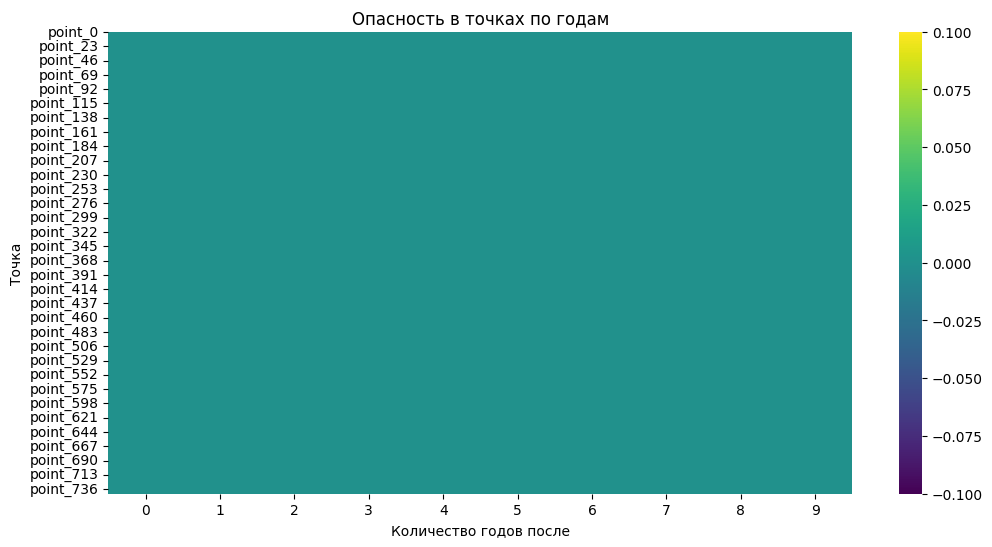

In [150]:
agent.predictions("flood", 10, 2)

### По тепловой карте можно сделать вывод, что от изменения температуры, которая была предсказана с помощью модели ARIMA, предсказания моделей либо не меняются, либо изменения минимальны

## Добавление к датасету новых данных из нового датасета и получение отчета о дрейфе данных

In [55]:
agent.fine_tuning(r"C:\Users\User\Desktop\Профики\MachineLearning\Проект №6 (последний срез)\clear_data.db")

## Полное переобучение моделей при новых данных и их сохранение

In [56]:
agent.fit_model("flood")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




In [57]:
agent.save_model("LogisticRegression")

In [58]:
agent.fit_model("fire")

Модель MLPClassifier:

Точность: 0.9994484280198566
Полнота: 0.9994484280198566
F1-метрика: 0.9994484280198566
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




In [59]:
agent.save_model("LogisticRegression")

In [60]:
agent.fit_model("evacuation")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




In [61]:
agent.save_model("LogisticRegression")

In [69]:
agent.fit_model("dangerous")

Модель MLPClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель GradientBoostingClassifier:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0


Модель LogisticRegression:

Точность: 1.0
Полнота: 1.0
F1-метрика: 1.0
ROC-AUC метрика: 1.0




In [70]:
agent.save_model("LogisticRegression")

## Просмотр логов

In [63]:
agent.get_log()

,time,name_log,model_name,info
0,2026-01-29 03:02:13.912488,Обучение моделей,*,Обучение трех моделей
1,2026-01-29 03:02:19.824069,Сохранение модели,LogisticRegression,Сохранение модели в файл
2,2026-01-29 03:02:21.160445,Обучение моделей,*,Обучение трех моделей
3,2026-01-29 03:02:23.337692,Сохранение модели,LogisticRegression,Сохранение модели в файл
4,2026-01-29 03:02:28.470099,Обучение моделей,*,Обучение трех моделей
5,2026-01-29 03:02:31.976639,Сохранение модели,LogisticRegression,Сохранение модели в файл
6,2026-01-29 03:02:39.143044,Сохранение модели,LogisticRegression,Сохранение модели в файл
7,2026-01-29 03:02:48.513705,Обучение моделей,*,Обучение трех моделей
8,2026-01-29 03:02:49.914754,Сохранение модели,LogisticRegression,Сохранение модели в файл
9,2026-01-29 03:02:50.759104,Обучение моделей,*,Обучение трех моделей


## Сохранение логов

In [64]:
agent.save_log()

'Логи сохранены!'